# Notizen: Kreuzungslogik & Duckiedetection

## Erkennen des Apriltags

**Problem:** Der Apriltag wird an der Kreuzung nicht erkannt, da der Bot zu nahe ist und der Apriltag nicht mehr im Sichtfeld ist.

**Idee:** Den oberen Bereich des Bildes analysieren (nicht nur den unteren), ob eine rote Linie darin ist – ähnlich wie beim "Kreuzung anhalten", jedoch nur um den zuletzt gesehenen Apriltag zu speichern. Dieser wird dann nach der Kreuzung zurückgesetzt.

## Befahren einer Kreuzung

**Idee:** Wenn Duckie an einer Kreuzung steht – Winkel und Entfernung zur Kreuzung berechnen.

**2 Möglichkeiten:**
1. An die Kreuzung fahren und anschließend `Kreuzung.py` ausführen
2. In `Kreuzung.py` diese Aktion mit aufnehmen, Fehler berechnen und darauf aufbauend die Kreuzung befahren

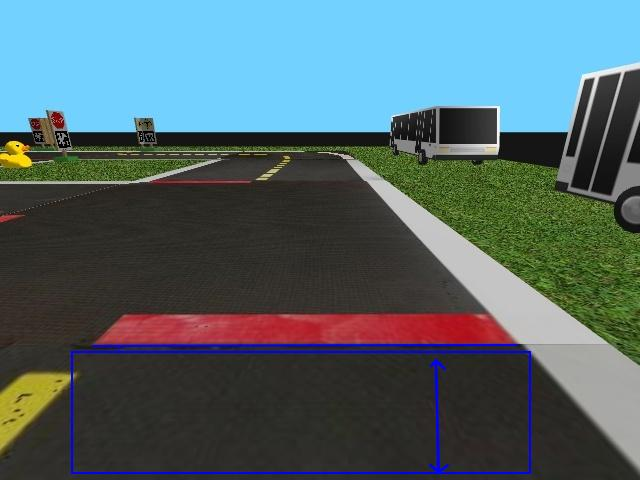

## Duckie Detection – Modell testen

In [10]:
import sys
!{sys.executable} -m pip install -q matplotlib onnxruntime

import onnxruntime as ort
import numpy as np
import cv2
from matplotlib import pyplot as plt

session = ort.InferenceSession("/tmp/duckie_v19.onnx")
input_name = session.get_inputs()[0].name
print("Modell geladen. Input:", session.get_inputs()[0].shape)

Modell geladen. Input: [1, 3, 480, 640]


In [11]:
IMAGE_PATH = "/root/DuckieRace/test12_jpg.rf.VS9nrHribjdSaafoxgHk.jpg"
CONF_THRESHOLD = 0.3

orig = cv2.imread(IMAGE_PATH)
img = cv2.resize(orig, (640, 480))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

inp = img_rgb.astype(np.float32) / 255.0
inp = np.transpose(inp, (2, 0, 1))
inp = np.expand_dims(inp, 0)

# Inferenz
raw_output = session.run(None, {input_name: inp})
detections = raw_output[0][0]  # shape: (300, 6) – alle erkannten Boxen

print(f"Output shape: {detections.shape}")

# Alle Boxen mit ausreichend hoher Confidence ausgeben
for i, box in enumerate(detections):
    x1, y1, x2, y2, conf, class_id = box
    if conf >= CONF_THRESHOLD:
        print(f"  Box {i}: x1={x1:.1f} y1={y1:.1f} x2={x2:.1f} y2={y2:.1f}  conf={conf:.3f}")

# Variable direkt anzeigen (erste 5 Boxen)
detections[:5]

Output shape: (300, 6)
  Box 0: x1=443.1 y1=302.5 x2=526.5 y2=390.8  conf=0.947
  Box 1: x1=370.2 y1=228.7 x2=417.2 y2=271.2  conf=0.902
  Box 2: x1=1.0 y1=233.7 x2=32.5 y2=277.8  conf=0.861
  Box 3: x1=75.5 y1=205.5 x2=90.2 y2=221.2  conf=0.849
  Box 4: x1=15.4 y1=218.0 x2=32.5 y2=234.2  conf=0.773
  Box 5: x1=42.0 y1=201.0 x2=53.1 y2=212.9  conf=0.678


array([[443.11063   , 302.48538   , 526.4647    , 390.7942    ,
          0.947335  ,   0.        ],
       [370.21628   , 228.67278   , 417.21567   , 271.1675    ,
          0.9015788 ,   0.        ],
       [  0.99515915, 233.68686   ,  32.45568   , 277.83908   ,
          0.8613162 ,   0.        ],
       [ 75.463745  , 205.49197   ,  90.15911   , 221.23413   ,
          0.849204  ,   0.        ],
       [ 15.3961525 , 217.95444   ,  32.451973  , 234.2084    ,
          0.7729201 ,   0.        ]], dtype=float32)

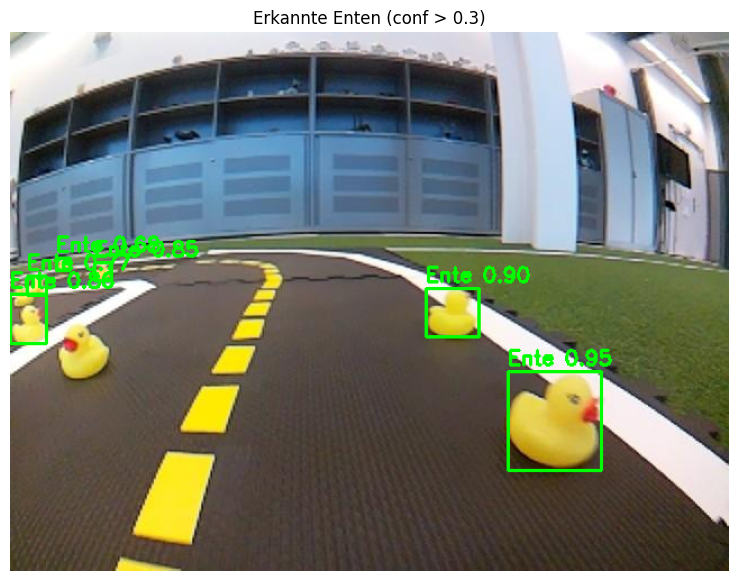

In [12]:
result_img = img_rgb.copy()

for box in detections:
    x1, y1, x2, y2, conf, class_id = box
    if conf < CONF_THRESHOLD:
        continue
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    cv2.rectangle(result_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(result_img, f"Ente {conf:.2f}", (x1, max(y1-6, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(12, 7))
plt.imshow(result_img)
plt.axis("off")
plt.title(f"Erkannte Enten (conf > {CONF_THRESHOLD})")
plt.show()

Logik zum Umfahren von Enten

![Dueckie Detection Logic.png](<attachment:Dueckie Detection Logic.png>)
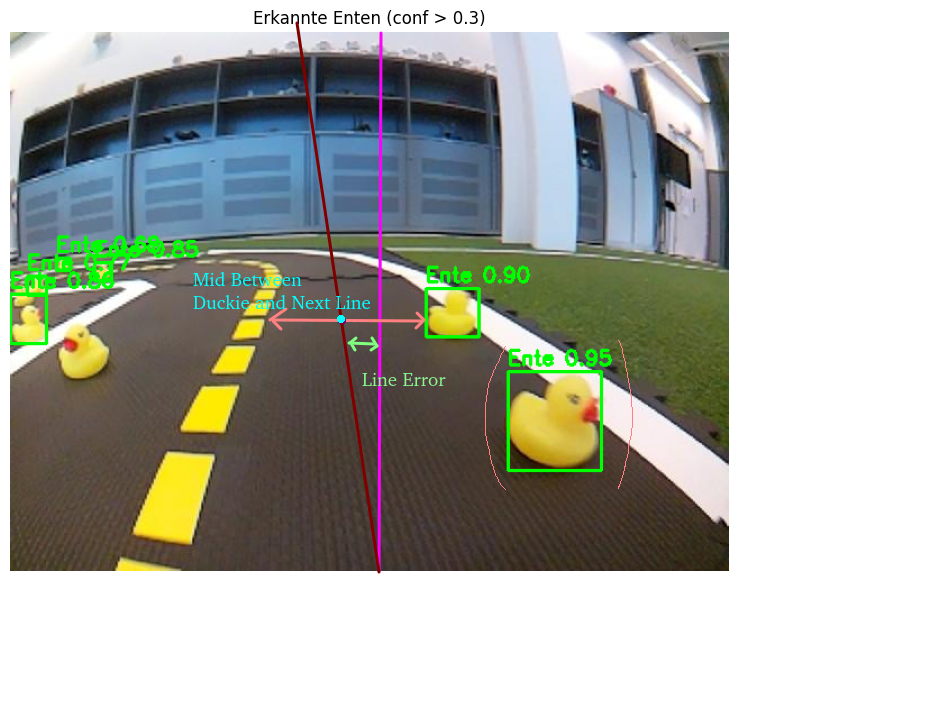

Idee: 
1. Enten und Fahrbahn linien erkennen
2. Abstand zwischen Enten und Linien ausrechnen
3. Breitesten Abstand zwischen Enten und Linien berechnen
4. Mittelpunkt ausrechnen
5. unterschied zwischen Mittelpunkt und "Fahrtrichtung" berechnen
6. PID-Regler?